In [1]:
import numpy as np 
from sklearn.datasets import fetch_olivetti_faces 
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler 
from sklearn.cluster import KMeans 
from sklearn.decomposition import PCA 
import matplotlib.pyplot as plt

In [2]:
# Load the Olivetti faces dataset 
faces = fetch_olivetti_faces()

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /home/shantanu/scikit_learn_data


In [3]:
data = faces.data 
targets = faces.target

In [4]:
# Split the dataset into training, validation, and test sets 
train_data, test_data, train_targets, test_targets = train_test_split( data, targets, test_size=0.2, stratify=targets, random_state=42 )

In [5]:
train_data, val_data, train_targets, val_targets = train_test_split( train_data, train_targets, test_size=0.25, stratify=train_targets, random_state=42 )

In [6]:
# Standardize the data (although it's already scaled, we'll apply PCA next)
scaler = StandardScaler()
train_data = scaler.fit_transform(train_data)
val_data = scaler.transform(val_data) 
test_data = scaler.transform(test_data)

In [7]:
# Apply PCA to reduce dimensionality
pca = PCA(n_components=150)
train_data_pca = pca.fit_transform(train_data)
val_data_pca = pca.transform(val_data)
test_data_pca = pca.transform(test_data)

In [8]:
# Determine the number of clusters using the elbow method
def plot_elbow_curve(data, max_k): 
    distortions = [] 
    for k in range(1, max_k + 1): 
        kmeans = KMeans(n_clusters=k, random_state=42) 
        kmeans.fit(data) 
        distortions.append(kmeans.inertia_)
    plt.figure(figsize=(8, 5)) 
    plt.plot(range(1, max_k + 1), distortions, marker='o') 
    plt.xlabel('Number of clusters') 
    plt.ylabel('Distortion') 
    plt.title('Elbow Curve') 
    plt.show()

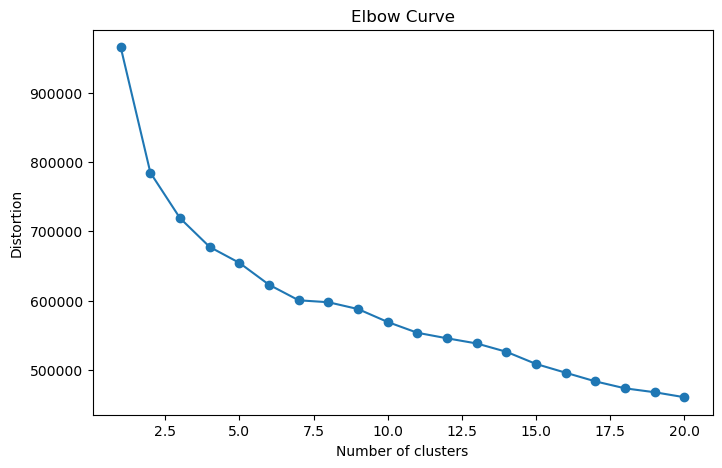

In [9]:
plot_elbow_curve(train_data_pca, 20)

In [10]:
# Fit K-means with the chosen number of clusters
kmeans = KMeans(n_clusters=10, random_state=42) 
kmeans.fit(train_data_pca)

KMeans(n_clusters=10, random_state=42)

In [11]:
# Predict clusters for the whole dataset
train_clusters = kmeans.predict(train_data_pca)
val_clusters = kmeans.predict(val_data_pca)
test_clusters = kmeans.predict(test_data_pca)

In [14]:
# Visualize some of the clusters
def plot_clusters(data, clusters, n_clusters, n_images=5): 
    plt.figure(figsize=(20, 10))
    for cluster in range(n_clusters):
        cluster_indices = np.where(clusters == cluster)[0]
        if len(cluster_indices) > 0:
            selected_indices = np.random.choice(cluster_indices, min(len(cluster_indices), n_images), replace=False)
            for i, index in enumerate(selected_indices):
                plt.subplot(n_clusters, n_images, cluster * n_images + i + 1)
                plt.imshow(data[index].reshape(64, 64), cmap='gray') 
                plt.axis('off')
    plt.show()


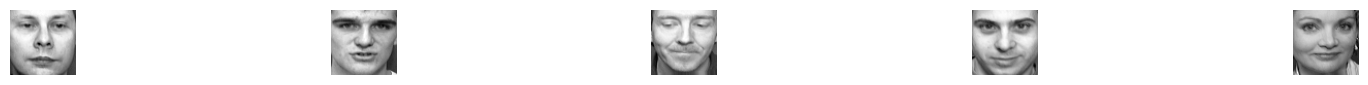

In [15]:
plot_clusters(data, kmeans.predict(pca.transform(data)), 10)